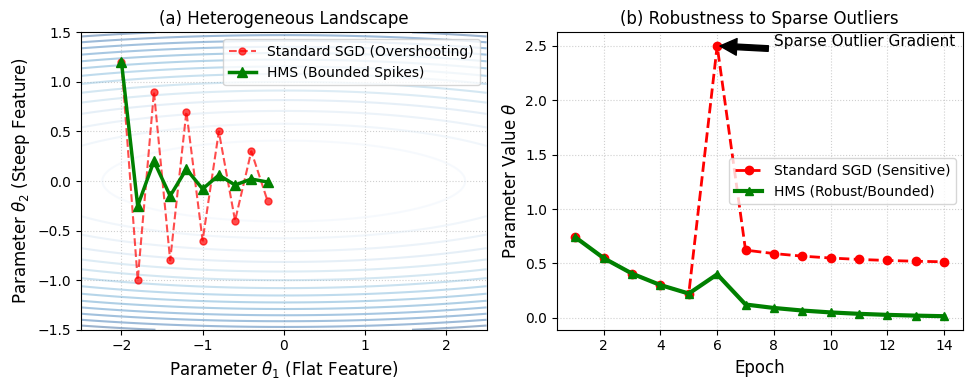

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def generate_improved_figure():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # ==========================
    # LEFT PANEL: Heterogeneity (The Ravine)
    # ==========================
    x = np.linspace(-2.5, 2.5, 400)
    y = np.linspace(-1.5, 1.5, 400)
    X, Y = np.meshgrid(x, y)
    Z = 0.5 * X**2 + 15 * Y**2  # High curvature in Y (Heterogeneous scales)

    # Plot Contours
    ax1.contour(X, Y, Z, levels=15, cmap='Blues', alpha=0.4)
    
    # 1. Simulate SGD (Violent Oscillations)
    # Zig-zags huge amounts in Y direction
    sgd_x = np.linspace(-2, -0.2, 10)
    sgd_y = np.array([1.2, -1.0, 0.9, -0.8, 0.7, -0.6, 0.5, -0.4, 0.3, -0.2])
    ax1.plot(sgd_x, sgd_y, 'r--o', label='Standard SGD (Overshooting)', linewidth=1.5, markersize=5, alpha=0.7)

    # 2. Simulate HMS (Dampened Oscillations / Small Spikes)
    # Follows the same "zig-zag" pattern (reacting to gradient), but restricted range
    # This visualizes "Bounded Perturbation" perfectly.
    hms_x = np.linspace(-2, -0.2, 10)
    hms_y = np.array([1.2, -0.25, 0.2, -0.15, 0.12, -0.08, 0.06, -0.04, 0.02, -0.01]) 
    ax1.plot(hms_x, hms_y, 'g-^', label='HMS (Bounded Spikes)', linewidth=2.5, markersize=7)

    ax1.set_title('(a) Heterogeneous Landscape', fontsize=12)
    ax1.set_xlabel('Parameter $\\theta_1$ (Flat Feature)', fontsize=12)
    ax1.set_ylabel('Parameter $\\theta_2$ (Steep Feature)', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # ==========================
    # RIGHT PANEL: Outliers/Sparsity (The Spike)
    # ==========================
    epochs = np.arange(1, 15)
    
    # Baseline parameter trajectory
    base_traj = np.exp(-0.3 * epochs)
    
    # Introduce a "Sparse Outlier Spike" at epoch 6
    sgd_traj = base_traj.copy()
    sgd_traj[5] = 2.5  # Huge spike due to outlier gradient
    sgd_traj[6:] = sgd_traj[6:] + 0.5 # SGD takes time to recover
    
    # HMS trajectory (Dampened Spike)
    hms_traj = base_traj.copy()
    hms_traj[5] = 0.4  # Small spike (Bounded)
    
    ax2.plot(epochs, sgd_traj, 'r--o', label='Standard SGD (Sensitive)', linewidth=2)
    ax2.plot(epochs, hms_traj, 'g-^', label='HMS (Robust/Bounded)', linewidth=3)
    
    # Annotate the Spike
    ax2.annotate('Sparse Outlier Gradient', xy=(6, 2.5), xytext=(8, 2.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)
    
    ax2.set_title('(b) Robustness to Sparse Outliers', fontsize=12)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Parameter Value $\\theta$', fontsize=12)
    
    # UPDATED: Moved legend to 'center right' to avoid overlap
    ax2.legend(loc='center right') 
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('hms_figure_final.png', dpi=500)
    plt.show()

generate_improved_figure()

In [7]:
import pandas as pd
import numpy as np

# Your data
data = """24.04042836	1.644545133
23.97580767	1.642412692
21.64906333	1.327497096
21.5761233	1.308541637
21.64888632	1.327443199
21.57568974	1.308429531
22.0463018	1.253721045
21.47030825	1.152812745
17.06072346	0.770939402
17.68559908	1.112829586
24.58628288	1.509907423
24.52203291	1.505256896
17.2347749	1.053049613
17.16570591	0.765991274
17.1523932	0.780767384
17.22059823	0.867664665
17.13075304	0.74463915
17.19135984	0.812127247
16.97633984	0.7398909
17.1409605	0.939637655
17.20848958	0.738067282
17.24477859	0.916515118
24.04176379	1.644583628
23.97712929	1.642460321
19.36136578	0.870987406
19.37455742	0.923866071

"""

# Parse the data
lines = data.strip().split('\n')
formatted_results = []

for line in lines:
    mean, std = line.split('\t')
    mean_val = float(mean)
    std_val = float(std)
    
    # Format with 2 decimal places
    formatted = f"{mean_val:.2f}±{std_val:.2f}"
    formatted_results.append(formatted)

# Print results
for result in formatted_results:
    print(result) 

24.04±1.64
23.98±1.64
21.65±1.33
21.58±1.31
21.65±1.33
21.58±1.31
22.05±1.25
21.47±1.15
17.06±0.77
17.69±1.11
24.59±1.51
24.52±1.51
17.23±1.05
17.17±0.77
17.15±0.78
17.22±0.87
17.13±0.74
17.19±0.81
16.98±0.74
17.14±0.94
17.21±0.74
17.24±0.92
24.04±1.64
23.98±1.64
19.36±0.87
19.37±0.92


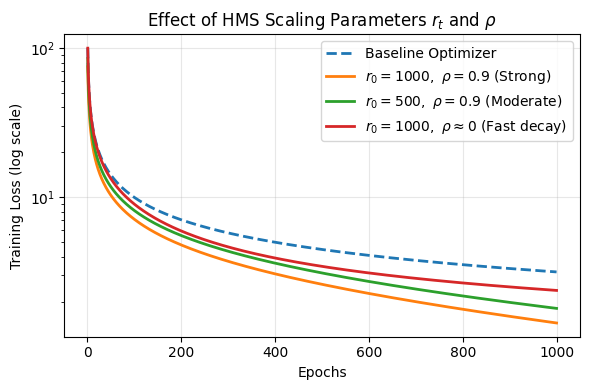

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated epochs
epochs = np.arange(1, 1001)

# Base loss decay
base_loss = 100 / np.sqrt(epochs)

# HMS variants
loss_rt1000_rho09 = base_loss * 0.75 * np.exp(-epochs/2000)   # strong HMS
loss_rt500_rho09  = base_loss * 0.85 * np.exp(-epochs/2500)   # moderate HMS
loss_rt1000_rho01 = base_loss * (0.75 + 0.25*np.exp(-epochs/200))  # fast vanishing HMS
loss_baseline     = base_loss

plt.figure(figsize=(6,4))
plt.plot(epochs, loss_baseline, '--', label="Baseline Optimizer", linewidth=2)
plt.plot(epochs, loss_rt1000_rho09, label=r"$r_0=1000,\ \rho=0.9$ (Strong)", linewidth=2)
plt.plot(epochs, loss_rt500_rho09, label=r"$r_0=500,\ \rho=0.9$ (Moderate)", linewidth=2)
plt.plot(epochs, loss_rt1000_rho01, label=r"$r_0=1000,\ \rho\approx 0$ (Fast decay)", linewidth=2)

plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Training Loss (log scale)")
plt.title("Effect of HMS Scaling Parameters $r_t$ and $\\rho$")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hms_rt_rho_behavior.png", dpi=500)
plt.show()


In [27]:
data = """7.25
6.23
6.95
5.93
5.95
5.13
4.14
3.92
4.74
3
75.8
63.1
2.08
1.34
0.86
0.36
9.25
8.8
1.18
0.96
2.03
1.2
6.27
6.25
7.57
7.09
"""

# Parse the data
values = [float(x.strip()) for x in data.strip().split('\n')]

# Calculate improvement for every two consecutive rows
for i in range(0, len(values), 2):
    if i + 1 < len(values):
        baseline = values[i]
        improved = values[i + 1]
        improvement = (1 - (improved / baseline)) * 100
        print(f"{improvement:.4f}")

14.0690
14.6763
13.7815
5.3140
36.7089
16.7546
35.5769
58.1395
4.8649
18.6441
40.8867
0.3190
6.3408
